# Tech Challenge Fase 1 - Case NPS Preditivo 

## 1. Entendimento do Negócio

Uma empresa de e-commerce teve um grande aumento de demanda devido à evolução da área de compras online no cenário nacional. Contudo, esse crescimento acelerado trouxe desafios em manter a qualidade da experiência para o usuário final, e esses problemas são refletidos nos resultados do NPS, onde é possível perceber que há uma grande quantidade de respostas não satisfatórias.

O NPS (Net Promoter Score, ou Pontuação Líquida de Promotores) é uma importante variável de saída que resume a experiência do cliente e define sua relação de fidelidade com a empresa. Através dessa variável várias áreas podem se beneficiar:

- Suporte e Atendimento ao Cliente: podem identificar os principais problemas que causam atrito com o cliente e atuar em possíveis churn;
- Logística: podem buscar melhorias na entrega, previsão das datas de entrega, estratégias de escoamento de produtos nas diversas regiões;
- Princing: melhorar a precificação dos produtos e oferecer descontos;
- Marketing: segmentação de clientes para criação de campanhas mais assertivas.

De maneira geral, o NPS impacta também outras importantes variáveis para e-commerce:
- Recompra: clientes que deram boas notas de NPS (Promotores) normalmente confiam na empresa e realizam mais compras futuras.
- Boca a boca: Promotres costumam indicar a empresa para outras pessoas de maneira orgânica (sem custo), enquanto Detratores podem indicar a concorrência ou mesmo difamar a empresa.
- Market share: com o efeito dos Promotores ou Detratores, no longo prazo, é possível ter uma maior ou menor parcela de participação das compras totais do mercado.
- Indicadores complementares: a partir do NPS é possível derivar outras variáveis de qualidade do serviço: comparação de NPS periódico ou da concorrência (benchmark), SLA logístico (entrega no prazo x atrasados), taxa de devolução.

## 2. Definição da Target

Iniciando uma análise superficial do dataset com os resultados de NPS `../data/desafio_nps_fase_1.csv`, podemos identificar que a variável target que representa a satisfação do cliente é o **`nps_score`**. Ela precisa ser a variável target pois é a pontuação final definida pelo cliente na pesquisa de satisfação. No caso do cenário atual que estamos trabalhando, essa variável é coletada no final da experiência de uma compra.

Um risco que devemos levar em consideração é justamente o momento da coleta: final da jornada de compra. É uma pesquisa reativa em que geralmente apenas clientes insatisfeitos ou que tiveram algum tipo de problema respondem. Portanto, os dados podem estar enviesados com informações em sua maioria negativas e podem não refletir a real situação reputacional da empresa quando comparado ao todo. Ou seja, se uma pesquisa de NPS possui 500 casos e, desses, 100% são detratores, pode ser que apenas 500 casos não sejam realmente um problema se o total de compras da empresa está na casa dos milhões. Por isso, é importante ter cuidado ao realizar a análise dos dados.

## 3. Análise Exploratória dos Dados (EDA)

Vamos iniciar a EDA, verificando os dados disponíveis no dataset, compreendendo as variáveis e casos e observando a integridade do conjunto do dados disponíveis.

### Verificação das características e integridade do dataset

In [12]:
import pandas as pd

df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


A visualização primária das características do dataset nos mostra a presença de 19 variáveis. Dessas variáveis, temos a seguinte classificação:
- qualitativas nominais:
  - custom_id, order_id, customer_region, repeat_purchase_30d
- quantitativas discretas:
  - customer_age, customer_tenure_months, items_quantity, payment_installments, delivery_time_days, delivery_delay_days, delivery_attempts, customer_service_contacts, resolution_time_days, complaints_count,
- quantitativas contínuas:
  - order_value, discount_value, freight_value, nps_score, csat_internal_score  

Essa abordagem irá facilitar nossa análise posterior, visto que cada tipo de variável suscita uma forma diferente de abordagem na análise exploratória

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Com base nas informações apresentadas sobre o dataset, identificamos 2500 casos, sendo todos eles não nulos. Ou seja, para cada um dos casos, os dados de todas as variáveis são existentes. Como nossa abordagem inicial perpassa apenas a análise descritiva dos dados e possuímos um dataset realtivamente pequeno, optamos por não colher amostras em um primeiro momento e lidar com o dataset completo, para compreender melhor os padrões iniciais que guiarão nossas análises futuras.

### Análise de dados de uma variável

In [14]:
df.describe(include='all')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1250.50000,43.396000,NaN,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,NaN,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,NaN,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,NaN,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,NaN,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,NaN,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000


#### Dados do cliente

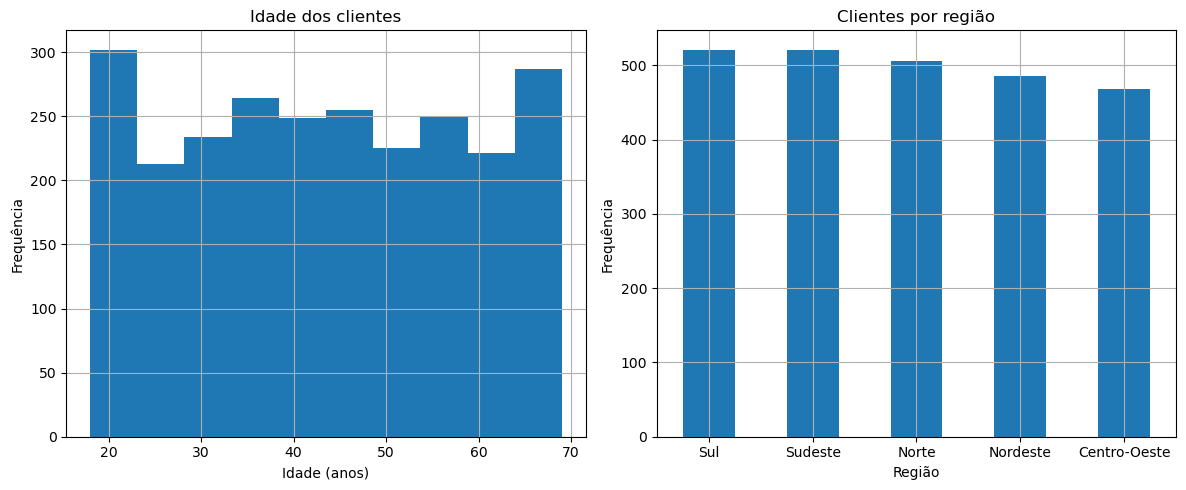

In [18]:
import matplotlib.pyplot as plt

#Grades do plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['customer_age'].hist(bins=10, ax = axs[0])
axs[0].set_title('Idade dos clientes')
axs[0].set_xlabel('Idade (anos)')
axs[0].set_ylabel('Frequência')
axs[0].grid(True)

# Gráfico 2, contendo a frequência por região geográfica. Utilizamos o tick_params para manter os rótulos das barras na horizontal
region_counts = df['customer_region'].value_counts().plot(kind='bar')
axs[1].set_title('Clientes por região')
axs[1].set_xlabel('Região')
axs[1].set_ylabel('Frequência')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Dados da encomenda

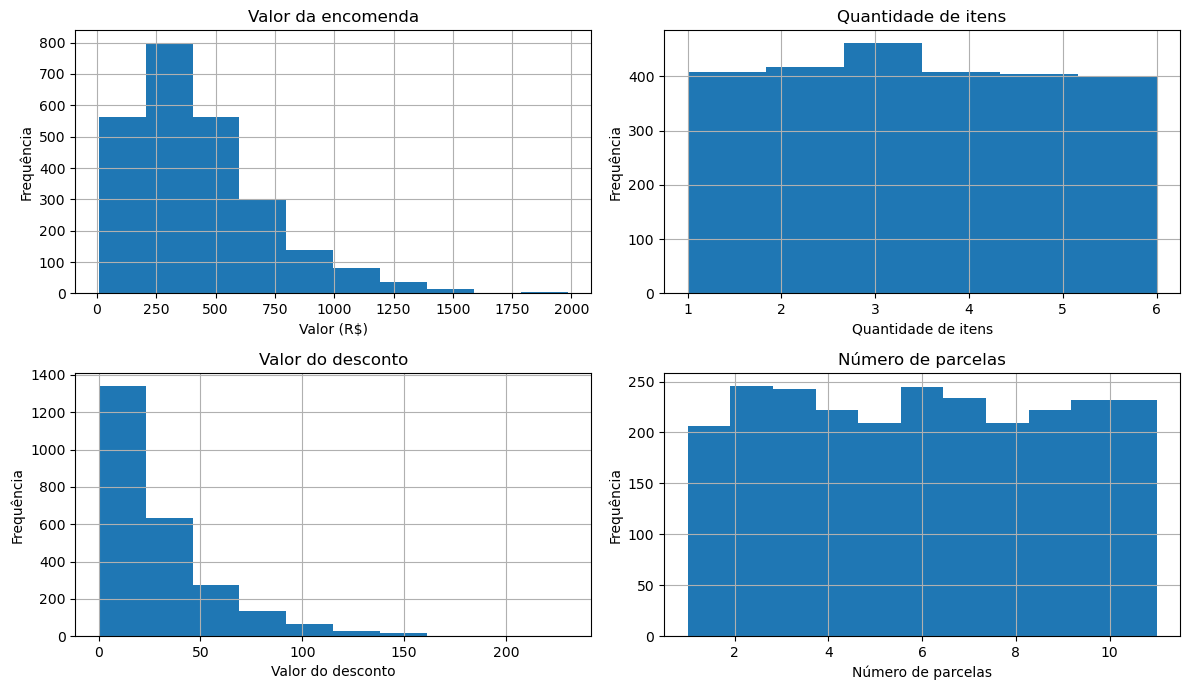

In [20]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 3, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['order_value'].hist(bins=10, ax = axs[0,0])
axs[0,0].set_xlabel('Valor (R$)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Valor da encomenda')
axs[0,0].grid(True)

# Gráfico 4, contendo o histograma da quantidade de itens por compra
df['items_quantity'].hist(bins=6, ax = axs[0,1])
axs[0,1].set_xlabel('Quantidade de itens')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Quantidade de itens')
axs[0,1].grid(True)

# Gráfico 5, contendo o histograma dos valores de desconto no valor do produto
df['discount_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do desconto')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do desconto')
axs[1,0].grid(True)

# Gráfico 6, contendo os dados de número de parcelas. Pelo fato de ser uma variável discreta, optamos por utilizar o valor máximo dela no número de bins
df['payment_installments'].hist(bins=11, ax = axs[1,1])
axs[1,1].set_xlabel('Número de parcelas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Número de parcelas')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()